<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_Eficiencia_Energetica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_excel('ENB2012_data.xlsx')

# 2. Renombrar columnas para mayor claridad
columnas = {
    'X1': 'Relative_Compactness', 'X2': 'Surface_Area', 'X3': 'Wall_Area',
    'X4': 'Roof_Area', 'X5': 'Overall_Height', 'X6': 'Orientation',
    'X7': 'Glazing_Area', 'X8': 'Glazing_Area_Dist',
    'Y1': 'Heating_Load', 'Y2': 'Cooling_Load'
}
df = df.rename(columns=columnas)

# 3. Exploración básica
print("Dimensiones del dataset")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\nVerificación de Nulos")
print(df.isnull().sum().sum(), "valores nulos encontrados.")

# Un vistazo rápido a los datos
display(df.head())

Dimensiones del dataset
Filas: 768, Columnas: 10

Verificación de Nulos
0 valores nulos encontrados.


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Dist,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [9]:
from sklearn.model_selection import train_test_split

# 1. Separar variables predictoras (X) de las objetivo (y)
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])
y = df[['Heating_Load', 'Cooling_Load']] # Doble corchete porque son DOS columnas a predecir

# 2. Dividir en entrenamiento (80%) y prueba (20%)
# ¿Por qué no usamos 'stratify'? Porque stratify es solo para CLASIFICACIÓN.
# Acá estamos prediciendo números continuos (REGRESIÓN).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos separados. Entrenamiento: {X_train.shape[0]} filas. Prueba: {X_test.shape[0]} filas.")

Datos separados. Entrenamiento: 614 filas. Prueba: 154 filas.


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Crear una función reciclable para no escribir las métricas 3 veces distintas.
# - RMSE penaliza los errores grandes.
# - MAE nos da el error promedio en las mismas unidades.
# - R² nos dice qué porcentaje del problema entendió el modelo.
def evaluar_regresion(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{nombre}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}\n")
    return rmse, mae, r2

# 1. Instanciar y Entrenar
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# 2. Evaluar
rmse_tree, mae_tree, r2_tree = evaluar_regresion("Árbol de Decisión", tree_model, X_test, y_test)

Árbol de Decisión
RMSE: 1.6938
MAE:  0.8362
R²:   0.9693



Random Forest
RMSE: 1.4666
MAE:  0.8053
R²:   0.9769



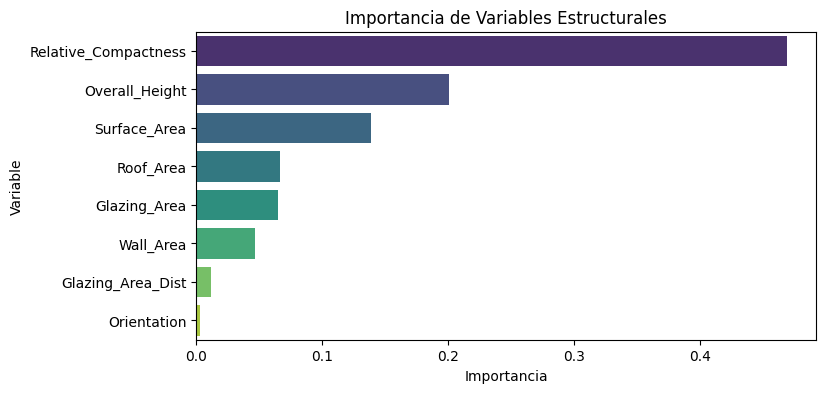

In [14]:
from sklearn.ensemble import RandomForestRegressor

# 1. Instanciar y Entrenar Random Forest
rf_model = RandomForestRegressor(n_estimators=100, min_samples_leaf=2, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Evaluar
rmse_rf, mae_rf, r2_rf = evaluar_regresion("Random Forest", rf_model, X_test, y_test)

# 3. Importancia de Variables
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=importancias_rf, x='Importancia', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Importancia de Variables Estructurales')
plt.show()

In [16]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# 1. Instanciar el modelo XGBoost
xgb_base = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

# 2. Envolverlo para Multi-Output y Entrenar
xgb_model = MultiOutputRegressor(xgb_base)
xgb_model.fit(X_train, y_train)

# 3. Evaluar
rmse_xgb, mae_xgb, r2_xgb = evaluar_regresion("XGBoost (Boosting)", xgb_model, X_test, y_test)

XGBoost (Boosting)
RMSE: 0.8541
MAE:  0.5310
R²:   0.9922



TABLA COMPARATIVA


,Modelo,RMSE,MAE,R²
0,Árbol de Decisión,1.693773,0.836182,0.969250
1,Random Forest,1.466619,0.805333,0.976932
2,XGBoost,0.854064,0.530959,0.992239


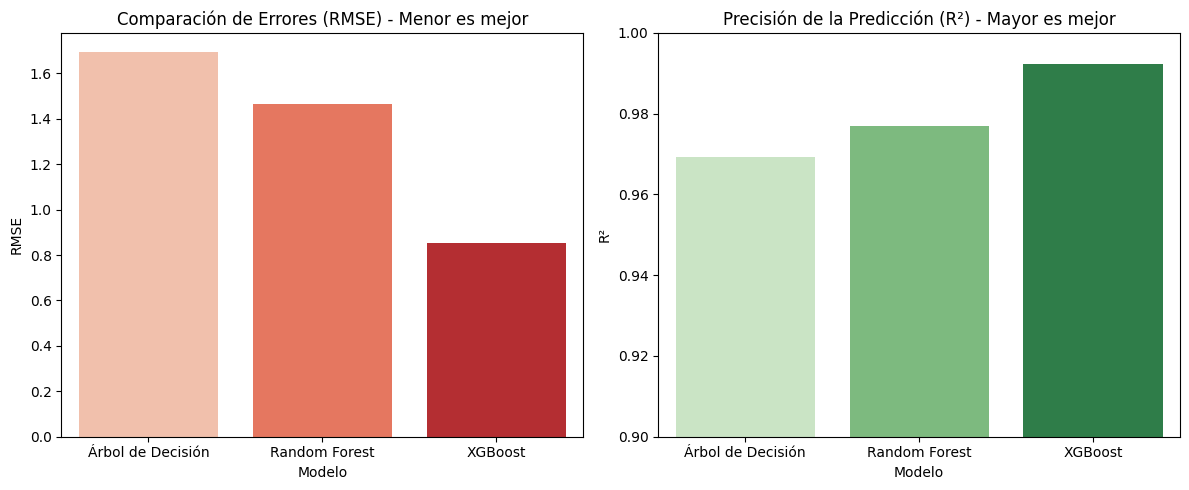

In [17]:
# 1. Crear tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_tree, rmse_rf, rmse_xgb],
    'MAE': [mae_tree, mae_rf, mae_xgb],
    'R²': [r2_tree, r2_rf, r2_xgb]
})

print("TABLA COMPARATIVA")
display(resultados)

# 2. Graficar RMSE y R²
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico RMSE
sns.barplot(data=resultados, x='Modelo', y='RMSE', ax=axes[0], hue='Modelo', palette='Reds', legend=False)
axes[0].set_title('Comparación de Errores (RMSE) - Menor es mejor')

# Gráfico R²
sns.barplot(data=resultados, x='Modelo', y='R²', ax=axes[1], hue='Modelo', palette='Greens', legend=False)
axes[1].set_title('Precisión de la Predicción (R²) - Mayor es mejor')
axes[1].set_ylim(0.9, 1.0) # Zoom para ver diferencias

plt.tight_layout()
plt.show()

### Reflexión Final y Conclusiones

**1. ¿Qué modelo recomendarías para un caso real de predicción energética?**
Recomendaría sin lugar a dudas el modelo **XGBoost**. Al observar la tabla comparativa, XGBoost logró minimizar el error de forma drástica (RMSE de 0.8541 frente a los 1.6938 del árbol base) y explica casi la totalidad de la varianza en los consumos energéticos con un espectacular **R² de 0.9922**. La diferencia de precisión justifica plenamente el pequeño costo computacional extra que requiere este ensamble avanzado.

**2. ¿Cómo influye el trade-off sesgo/varianza en Random Forest y en XGBoost?**
* En el **Árbol de Decisión base**, la *varianza* es alta: el modelo se ajusta demasiado al set de entrenamiento pero le cuesta generalizar ante datos nuevos.
* **Random Forest (Bagging)** reduce esta *varianza* promediando 100 árboles distintos entrenados en paralelo, logrando un modelo mucho más estable (mejorando el R² a 0.9769).
* **XGBoost (Boosting)** ataca el *sesgo* (bias) entrenando árboles de manera secuencial, donde cada nuevo árbol se enfoca milimétricamente en corregir los errores residuales del anterior. Esto permite un ajuste casi perfecto a los complejos patrones de consumo del edificio.

**3. ¿Qué ventajas y desventajas encontraste en cada técnica?**
* **Árbol de Decisión:**
  * *Ventaja:* 100% interpretable, visualizable y rapidísimo de entrenar.
  * *Desventaja:* Peor rendimiento predictivo general y alta tendencia al sobreajuste (*overfitting*).
* **Random Forest:**
  * *Ventaja:* Muy robusto "fuera de la caja" (no requiere ajustar muchos hiperparámetros) y nos entrega el gráfico de *Feature Importance* para extraer insights de negocio (ej. descubrir que la altura y la compacidad son los factores críticos).
  * *Desventaja:* Los ensambles de cientos de árboles profundos pueden ser muy pesados en memoria RAM.
* **XGBoost:**
  * *Ventaja:* Es el modelo campeón absoluto en precisión gracias a su optimización matemática (gradiente y penalización para evitar sobreajuste).
  * *Desventaja:* Para poder predecir dos columnas a la vez (Heating y Cooling Load) requirió utilizar el envoltorio extra `MultiOutputRegressor`, y posee muchos más hiperparámetros que calibrar que un Random Forest.